# Удалённая работа в криптовалюте / Web3 для разработчика (2025 / 2026)

## Прикладной проект на реальных данных

Ты — **разработчик**, и хочешь понять рынок **удалённых вакансий в крипто/Web3**:
где платят больше, какой стек и грейд выгоднее, насколько рискованна оплата в
токенах и какие роли самые востребованные.

**Вопросы проекта:**
1. Какие роли и стеки (Solidity, Rust, ZK, Go/TS…) дают максимальную зарплату?
2. Как растёт доход по грейдам **junior → middle → senior**?
3. Где выше спрос (доля вакансий) и как совместить «деньги + спрос + стабильность»?
4. Насколько рискованна часть компенсации в **токенах/equity** — оценим методом
   **Монте-Карло** (тема нашего курса вероятностей).
5. Как выглядят реальные вакансии прямо сейчас — подтянем их из **публичного API
   RemoteOK** (с оффлайн-фолбэком).

> ⚠️ **Про данные.** Базовый датасет — это агрегированный **срез 2025 года** по
> открытым источникам (см. раздел «Источники»). Цифры зарплат в крипто сильно
> разбросаны; трактуй их как ориентиры, а не как точные значения по конкретной
> вакансии. Живой блок тянет вакансии из RemoteOK API в реальном времени.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
pd.set_option('display.width', 180)
pd.set_option('display.max_columns', 30)
np.random.seed(42)

print('Библиотеки успешно загружены!')

Библиотеки успешно загружены!


## 1. Данные: роли, стек, грейды, спрос и доля оплаты в токенах

Срез 2025 года по удалённым Web3-вакансиям (глобальный рынок, оплата в USD/год).
Для каждой роли храним:

| Поле | Смысл |
|---|---|
| `jr / mid / sr` | медианная годовая зарплата по грейдам (USD, полная занятость) |
| `openings_pct` | доля роли среди всех dev-вакансий Web3 (спрос) |
| `token_pct` | какая часть компенсации приходится на **токены/equity** (риск/апсайд) |
| `stack` | ключевой стек роли |

Источники: web3.career, CryptoJobsList, Cryptocurrency Jobs, Electric Capital
*Developer Report 2024/25*, Stack Overflow Survey 2024.

In [2]:
# role -> (jr, mid, sr, openings_pct, token_pct, stack)
SNAPSHOT = {
    'Smart Contract Engineer': (90_000, 150_000, 220_000, 22, 0.25, 'Solidity/EVM'),
    'ZK Engineer':             (120_000, 190_000, 280_000, 3,  0.35, 'Circom/Rust/Math'),
    'Security Auditor':        (100_000, 170_000, 260_000, 6,  0.20, 'Solidity/Foundry'),
    'Protocol Engineer':       (110_000, 170_000, 250_000, 5,  0.35, 'Rust/Go'),
    'Rust Engineer':           (100_000, 160_000, 230_000, 9,  0.25, 'Rust (Solana/Cosmos)'),
    'Blockchain Backend':      (85_000,  140_000, 200_000, 13, 0.15, 'Go/Node/Postgres'),
    'DevOps / Infra':          (90_000,  145_000, 205_000, 8,  0.12, 'K8s/nodes/validators'),
    'Full-Stack Web3':         (80_000,  130_000, 190_000, 14, 0.15, 'TS/React/ethers.js'),
    'Frontend Web3':           (75_000,  120_000, 175_000, 16, 0.12, 'React/wagmi/viem'),
    'On-chain Data Analyst':   (80_000,  130_000, 180_000, 4,  0.12, 'SQL/Dune/Python'),
}

df = pd.DataFrame(
    [(r, *v) for r, v in SNAPSHOT.items()],
    columns=['role', 'jr', 'mid', 'sr', 'openings_pct', 'token_pct', 'stack']
).set_index('role')

print('Ролей в датасете:', len(df), '| сумма openings_pct =', df['openings_pct'].sum(), '%')
df

Ролей в датасете: 10 | сумма openings_pct = 100 %


,jr,mid,sr,openings_pct,token_pct,stack
role,,,,,,
Smart Contract Engineer,90000,150000,220000,22,0.25,Solidity/EVM
ZK Engineer,120000,190000,280000,3,0.35,Circom/Rust/Math
Security Auditor,100000,170000,260000,6,0.20,Solidity/Foundry
Protocol Engineer,110000,170000,250000,5,0.35,Rust/Go
Rust Engineer,100000,160000,230000,9,0.25,Rust (Solana/Cosmos)
Blockchain Backend,85000,140000,200000,13,0.15,Go/Node/Postgres
DevOps / Infra,90000,145000,205000,8,0.12,K8s/nodes/validators
Full-Stack Web3,80000,130000,190000,14,0.15,TS/React/ethers.js
Frontend Web3,75000,120000,175000,16,0.12,React/wagmi/viem


## 2. Зарплаты по ролям и грейдам

Посмотрим на «вилку» junior → senior и на прирост дохода по грейдам.

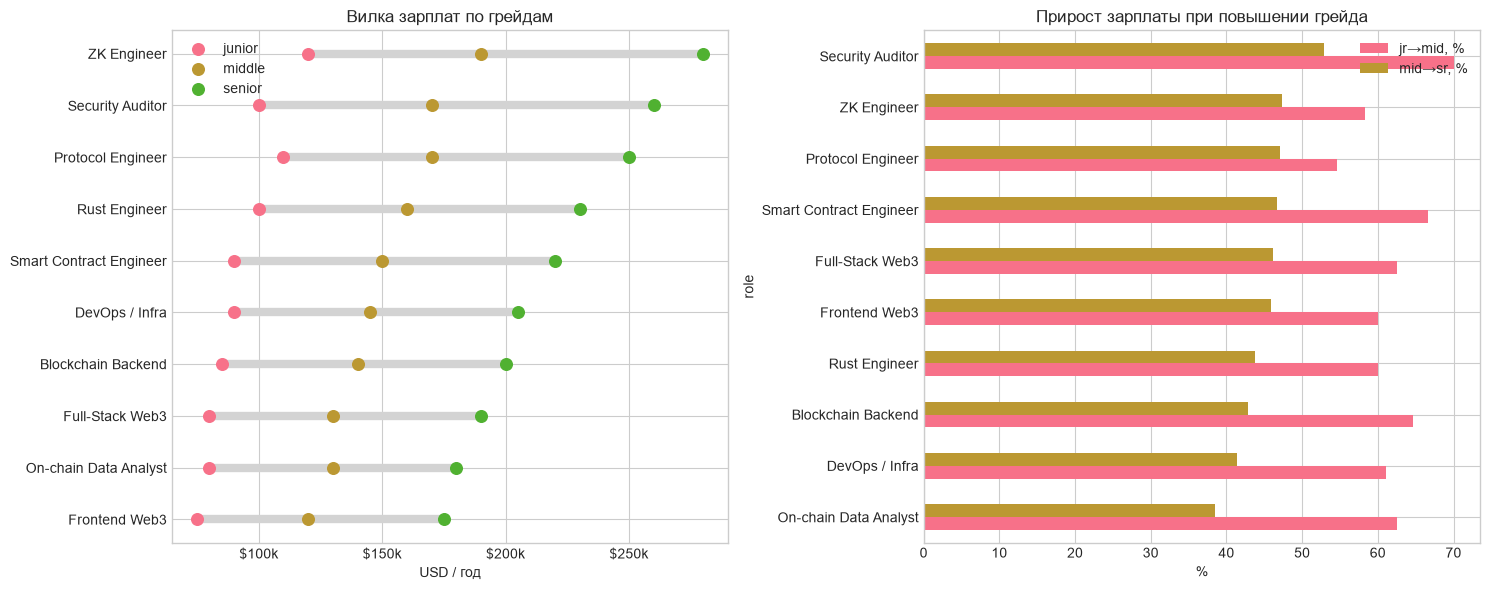

Средний прирост jr→mid: 62%,  mid→sr: 45%


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

d = df.sort_values('sr')
y = np.arange(len(d))
ax = axes[0]
ax.hlines(y, d['jr'], d['sr'], color='lightgray', lw=6, zorder=1)
ax.scatter(d['jr'],  y, s=70, label='junior', zorder=2)
ax.scatter(d['mid'], y, s=70, label='middle', zorder=2)
ax.scatter(d['sr'],  y, s=70, label='senior', zorder=2)
ax.set_yticks(y); ax.set_yticklabels(d.index)
ax.set_xlabel('USD / год'); ax.set_title('Вилка зарплат по грейдам')
ax.legend(); ax.xaxis.set_major_formatter(lambda x, _: f'${x/1000:.0f}k')

# прирост при переходе грейда
growth = pd.DataFrame({
    'jr→mid, %': (df['mid']/df['jr']-1)*100,
    'mid→sr, %': (df['sr']/df['mid']-1)*100,
}).sort_values('mid→sr, %')
growth.plot(kind='barh', ax=axes[1])
axes[1].set_title('Прирост зарплаты при повышении грейда')
axes[1].set_xlabel('%')
plt.tight_layout(); plt.show()

print('Средний прирост jr→mid: {:.0f}%,  mid→sr: {:.0f}%'.format(
    growth['jr→mid, %'].mean(), growth['mid→sr, %'].mean()))

## 3. Спрос: доля вакансий по ролям

Высокая зарплата бесполезна, если вакансий мало. Совместим «деньги» и «спрос».

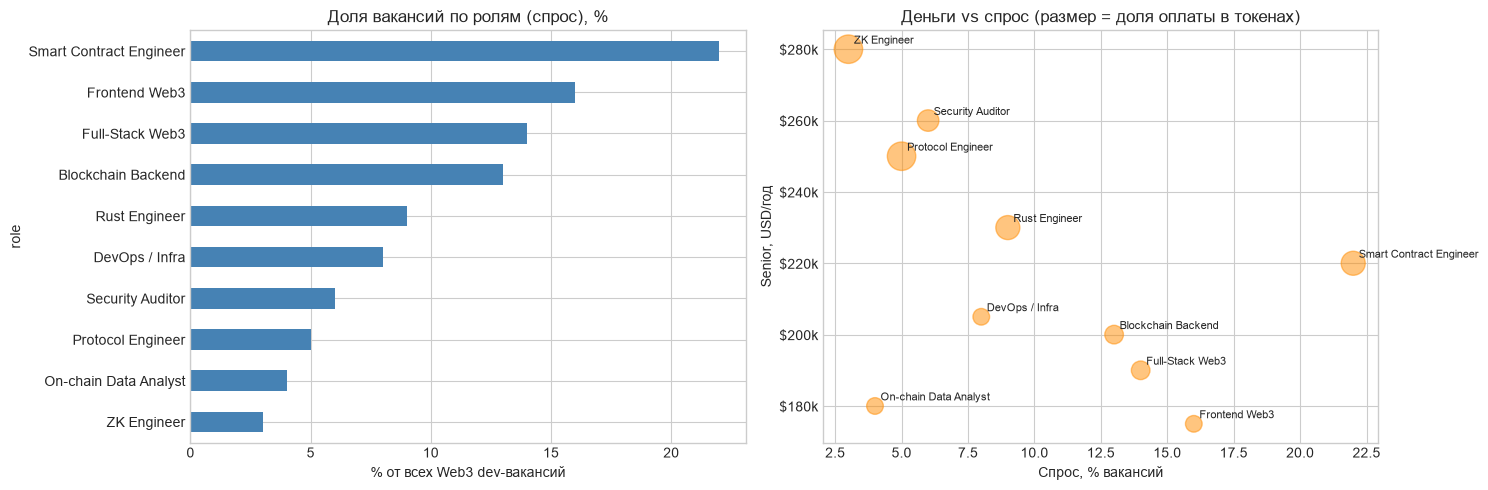

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

df['openings_pct'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Доля вакансий по ролям (спрос), %')
axes[0].set_xlabel('% от всех Web3 dev-вакансий')

# деньги (senior) vs спрос — пузырьки размером с token_pct
ax = axes[1]
ax.scatter(df['openings_pct'], df['sr'], s=df['token_pct']*1200,
           alpha=0.5, color='darkorange')
for r, row in df.iterrows():
    ax.annotate(r, (row['openings_pct'], row['sr']), fontsize=8,
                xytext=(4, 4), textcoords='offset points')
ax.set_xlabel('Спрос, % вакансий'); ax.set_ylabel('Senior, USD/год')
ax.set_title('Деньги vs спрос (размер = доля оплаты в токенах)')
ax.yaxis.set_major_formatter(lambda x, _: f'${x/1000:.0f}k')
plt.tight_layout(); plt.show()

## 4. Экосистемы: где сидят разработчики (Electric Capital)

Спрос на конкретный стек зависит от того, в каких **блокчейн-экосистемах** больше
активных разработчиков. Данные — *Electric Capital Developer Report 2024/25*
(ежемесячно активные разработчики, MAD). Цифры приблизительные (порядки величин),
но хорошо показывают расстановку сил и языковую специализацию.

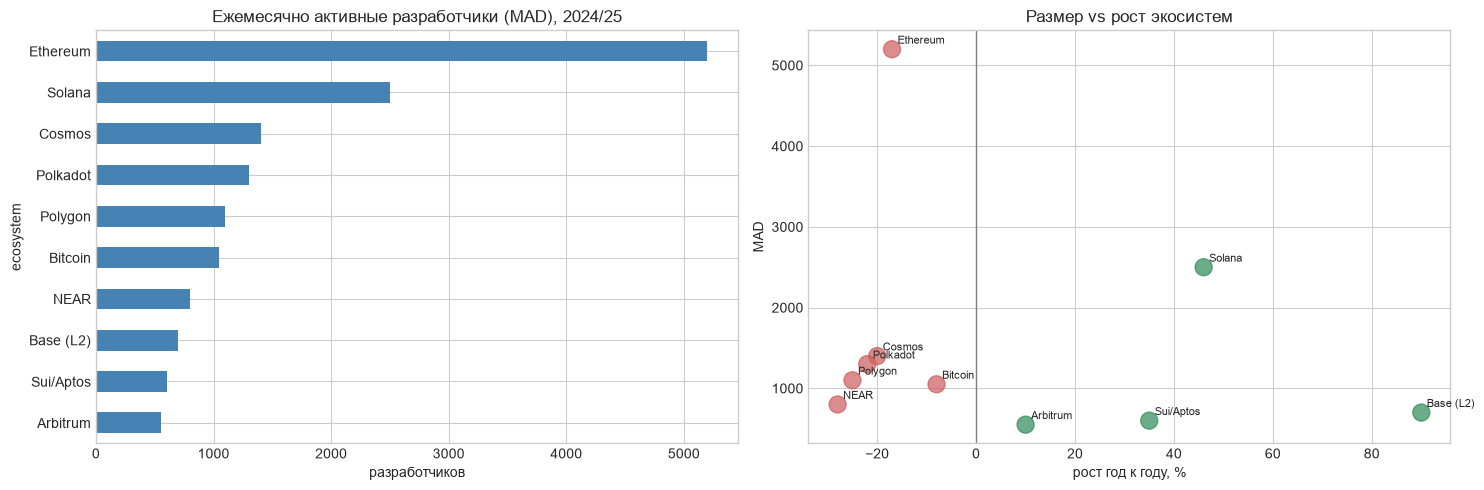

Крупнейшая экосистема: Ethereum (5200 MAD)
Быстрее всех растёт:  Base (L2) (+90% YoY)


In [5]:
# ecosystem -> (monthly_active_devs, рост YoY %, основной язык)
ECO = {
    'Ethereum':  (5200, -17, 'Solidity'),
    'Solana':    (2500,  46, 'Rust'),
    'Cosmos':    (1400, -20, 'Go/Rust'),
    'Polkadot':  (1300, -22, 'Rust'),
    'Polygon':   (1100, -25, 'Solidity'),
    'Bitcoin':   (1050,  -8, 'C++/Rust'),
    'NEAR':      ( 800, -28, 'Rust'),
    'Base (L2)': ( 700,  90, 'Solidity'),
    'Sui/Aptos': ( 600,  35, 'Move'),
    'Arbitrum':  ( 550,  10, 'Solidity'),
}
eco = pd.DataFrame([(k, *v) for k, v in ECO.items()],
                   columns=['ecosystem', 'devs', 'yoy', 'language']).set_index('ecosystem')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
eco['devs'].sort_values().plot(kind='barh', ax=axes[0], color='steelblue')
axes[0].set_title('Ежемесячно активные разработчики (MAD), 2024/25')
axes[0].set_xlabel('разработчиков')

colors = ['seagreen' if y > 0 else 'indianred' for y in eco['yoy']]
axes[1].scatter(eco['yoy'], eco['devs'], s=150, c=colors, alpha=0.7)
for name, row in eco.iterrows():
    axes[1].annotate(name, (row['yoy'], row['devs']), fontsize=8,
                     xytext=(4, 4), textcoords='offset points')
axes[1].axvline(0, color='gray', lw=1)
axes[1].set_xlabel('рост год к году, %'); axes[1].set_ylabel('MAD')
axes[1].set_title('Размер vs рост экосистем')
plt.tight_layout(); plt.show()

print('Крупнейшая экосистема:', eco['devs'].idxmax(), f"({eco['devs'].max()} MAD)")
print('Быстрее всех растёт: ', eco['yoy'].idxmax(), f"(+{eco['yoy'].max()}% YoY)")

In [6]:
# Суммарный спрос по языку (сумма MAD) vs senior-зарплата ролей на этом языке (df из раздела 1)
lang_devs = eco.groupby('language')['devs'].sum().sort_values(ascending=False)

LANG_TO_SR = {
    'Solidity':  df.loc[['Smart Contract Engineer', 'Security Auditor'], 'sr'].mean(),
    'Rust':      df.loc[['Rust Engineer', 'Protocol Engineer'], 'sr'].mean(),
    'Go/Rust':   df.loc['Blockchain Backend', 'sr'],
    'C++/Rust':  200_000,
    'Move':      190_000,   # новые L1 (Sui/Aptos), близко к Rust
}
comp = pd.DataFrame({'devs_MAD': lang_devs})
comp['sr_salary'] = comp.index.map(lambda l: LANG_TO_SR.get(l, np.nan))
print('Спрос (сумма MAD) и senior-зарплата по языку:')
print('=' * 50)
print(comp.dropna().assign(
    sr_salary=lambda d: d['sr_salary'].map('${:,.0f}'.format)).to_string())

print('\nВывод: EVM/Solidity — больше всего экосистем и вакансий (широкий спрос);')
print('Rust-экосистемы (Solana/Polkadot/Cosmos/NEAR) — крупный пул при высокой оплате;')
print('Move (Sui/Aptos) — небольшой, но быстрорастущий и хорошо оплачиваемый нишевый стек.')

Спрос (сумма MAD) и senior-зарплата по языку:
          devs_MAD sr_salary
language                    
Solidity      7550  $240,000
Rust          4600  $240,000
Go/Rust       1400  $200,000
C++/Rust      1050  $200,000
Move           600  $190,000

Вывод: EVM/Solidity — больше всего экосистем и вакансий (широкий спрос);
Rust-экосистемы (Solana/Polkadot/Cosmos/NEAR) — крупный пул при высокой оплате;
Move (Sui/Aptos) — небольшой, но быстрорастущий и хорошо оплачиваемый нишевый стек.


## 5. Оплата в токенах: риск и апсайд (Монте-Карло)

Часть компенсации в Web3 выдаётся **токенами/equity**. Их ценность через год —
случайная величина с высокой волатильностью. Смоделируем реализованную
компенсацию senior-разработчика.

**Модель.** Пусть годовой пакет $C$ = senior-зарплата. Доля `token_pct` выдаётся
токенами, остальное — стабильная фиатная база:

$$\text{base} = (1-\theta)\,C, \qquad \text{grant} = \theta\,C$$

Через год множитель стоимости токена $m \sim \text{LogNormal}(\mu=0,\ \sigma=0.8)$
(медиана 1.0, сильный правый хвост — крипто-апсайд). Реализованная компенсация:

$$C_{\text{real}} = \text{base} + m \cdot \text{grant}$$

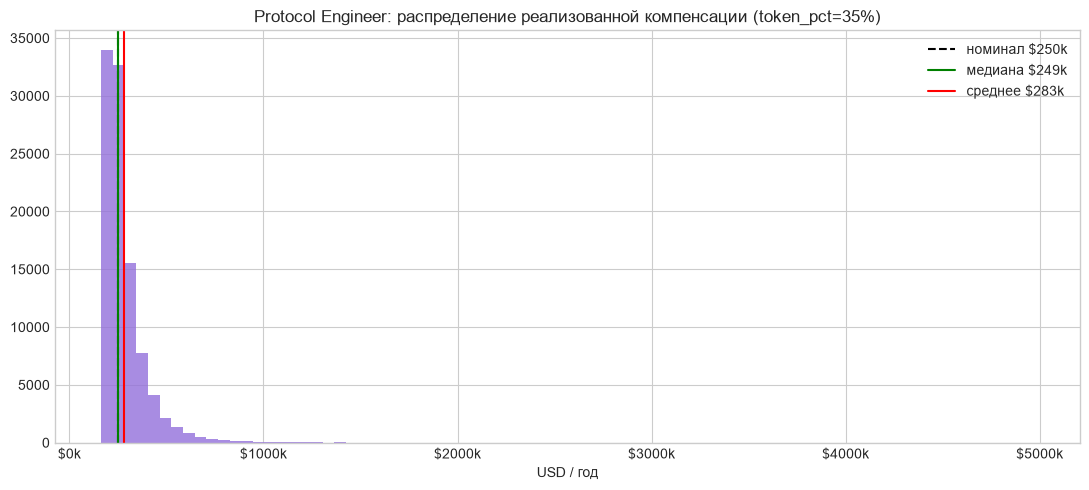

P(получить меньше номинала)      = 50.4%
P(потерять >20% от номинала)      = 14.6%
Среднее > медианы на             = $34k  (правый хвост/апсайд)


In [7]:
def simulate_comp(total, token_pct, sigma=0.8, n=100_000, seed=42):
    rng = np.random.default_rng(seed)
    base = (1 - token_pct) * total
    grant = token_pct * total
    m = rng.lognormal(mean=0.0, sigma=sigma, size=n)   # медиана = 1.0
    return base + m * grant

role = 'Protocol Engineer'   # высокая доля токенов (0.35)
tot = df.loc[role, 'sr']; th = df.loc[role, 'token_pct']
sim = simulate_comp(tot, th)

fig, ax = plt.subplots(figsize=(11, 5))
ax.hist(sim, bins=80, color='mediumpurple', alpha=0.8)
ax.axvline(tot, color='black', ls='--', label=f'номинал ${tot/1000:.0f}k')
ax.axvline(np.median(sim), color='green', ls='-', label=f'медиана ${np.median(sim)/1000:.0f}k')
ax.axvline(np.mean(sim), color='red', ls='-', label=f'среднее ${np.mean(sim)/1000:.0f}k')
ax.set_title(f'{role}: распределение реализованной компенсации (token_pct={th:.0%})')
ax.set_xlabel('USD / год'); ax.legend()
ax.xaxis.set_major_formatter(lambda x, _: f'${x/1000:.0f}k')
plt.tight_layout(); plt.show()

p_below = (sim < tot).mean()
p_loss20 = (sim < 0.8*tot).mean()
print(f'P(получить меньше номинала)      = {p_below:.1%}')
print(f'P(потерять >20% от номинала)      = {p_loss20:.1%}')
print(f'Среднее > медианы на             = ${(sim.mean()-np.median(sim))/1000:.0f}k  (правый хвост/апсайд)')

## 6. Композитный рейтинг ролей для разработчика

Совместим три фактора через **z-оценки** (стандартизация) с весами:

$$\text{score} = 0.40\,z(\text{senior}) + 0.30\,z(\text{спрос}) - 0.30\,z(\text{token\_pct})$$

Больше денег и спроса — лучше; выше доля токенов — рискованнее (минус).

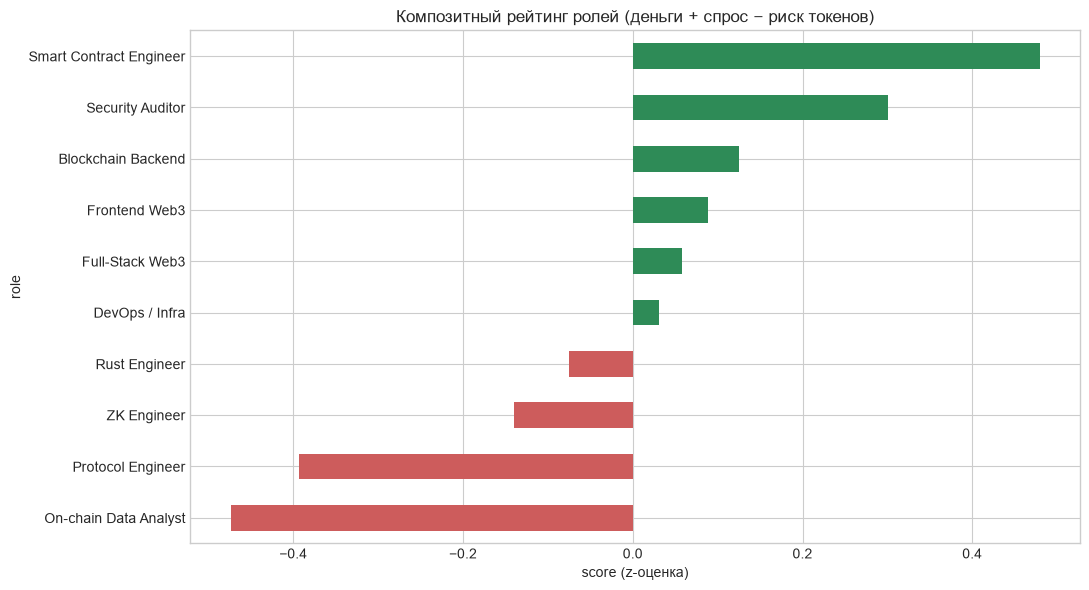

,stack,sr,openings_pct,token_pct,score
role,,,,,
Smart Contract Engineer,Solidity/EVM,220000,22,0.25,0.479
Security Auditor,Solidity/Foundry,260000,6,0.20,0.301
Blockchain Backend,Go/Node/Postgres,200000,13,0.15,0.125
Frontend Web3,React/wagmi/viem,175000,16,0.12,0.088
Full-Stack Web3,TS/React/ethers.js,190000,14,0.15,0.058
DevOps / Infra,K8s/nodes/validators,205000,8,0.12,0.030
Rust Engineer,Rust (Solana/Cosmos),230000,9,0.25,-0.075
ZK Engineer,Circom/Rust/Math,280000,3,0.35,-0.140
Protocol Engineer,Rust/Go,250000,5,0.35,-0.393


In [8]:
def zscore(s):
    return (s - s.mean()) / s.std(ddof=0)

WEIGHTS = {'sr': 0.40, 'openings_pct': 0.30, 'token_pct': -0.30}

def composite(data, weights):
    score = pd.Series(0.0, index=data.index)
    for col, w in weights.items():
        score += w * zscore(data[col])
    return score

df['score'] = composite(df, WEIGHTS)
rank = df.sort_values('score', ascending=False)

fig, ax = plt.subplots(figsize=(11, 6))
colors = ['seagreen' if s > 0 else 'indianred' for s in rank['score']]
rank['score'].iloc[::-1].plot(kind='barh', ax=ax, color=colors[::-1])
ax.set_title('Композитный рейтинг ролей (деньги + спрос − риск токенов)')
ax.set_xlabel('score (z-оценка)')
plt.tight_layout(); plt.show()

rank[['stack', 'sr', 'openings_pct', 'token_pct', 'score']].round(3)

### Сценарии приоритетов

Один вес не подходит всем. Сравним три стратегии выбора роли:
- **Максимум денег** — важен только senior-доход;
- **Максимум спроса** — легче найти работу и сменить её;
- **Максимум стабильности** — минимум оплаты в токенах.

In [9]:
scenarios = {
    'Баланс':             {'sr': 0.40, 'openings_pct': 0.30, 'token_pct': -0.30},
    'Максимум денег':     {'sr': 0.80, 'openings_pct': 0.10, 'token_pct': -0.10},
    'Максимум спроса':    {'sr': 0.20, 'openings_pct': 0.70, 'token_pct': -0.10},
    'Максимум стабильности': {'sr': 0.30, 'openings_pct': 0.20, 'token_pct': -0.50},
}

top = {}
for name, w in scenarios.items():
    top[name] = composite(df, w).sort_values(ascending=False).head(3).index.tolist()

top_df = pd.DataFrame(top, index=['#1', '#2', '#3'])
print('Топ-3 роли по сценариям:\n')
print(top_df.to_string())

Топ-3 роли по сценариям:

                     Баланс     Максимум денег          Максимум спроса Максимум стабильности
#1  Smart Contract Engineer        ZK Engineer  Smart Contract Engineer         Frontend Web3
#2         Security Auditor   Security Auditor            Frontend Web3        DevOps / Infra
#3       Blockchain Backend  Protocol Engineer          Full-Stack Web3      Security Auditor


## 7. Живые данные: вакансии из RemoteOK API

[RemoteOK](https://remoteok.com/) отдаёт публичный JSON без ключа. Подтянем
свежие удалённые вакансии, отфильтруем крипто/Web3-теги и посмотрим на реальные
зарплатные вилки прямо сейчас.

> Если сети нет (в изолированном окружении) — используется оффлайн-срез, а код
> живого запроса остаётся полностью рабочим при наличии интернета.

In [10]:
import json
from urllib.request import Request, urlopen

CRYPTO_TAGS = {'crypto', 'web3', 'blockchain', 'solidity', 'defi', 'ethereum',
               'bitcoin', 'nft', 'smart contract', 'rust'}

def fetch_remoteok(timeout=6):
    req = Request('https://remoteok.com/api',
                  headers={'User-Agent': 'Mozilla/5.0 (research notebook)'})
    with urlopen(req, timeout=timeout) as r:
        data = json.loads(r.read().decode('utf-8'))
    # первый элемент — легенда/метаданные, пропускаем
    jobs = [j for j in data if isinstance(j, dict) and j.get('position')]
    rows = []
    for j in jobs:
        tags = {str(t).lower() for t in j.get('tags', [])}
        if tags & CRYPTO_TAGS:
            rows.append({
                'position': j.get('position'),
                'company':  j.get('company'),
                'salary_min': j.get('salary_min'),
                'salary_max': j.get('salary_max'),
                'tags': ', '.join(sorted(tags & CRYPTO_TAGS)),
            })
    return pd.DataFrame(rows)

try:
    live = fetch_remoteok()
    if live.empty:
        raise ValueError('нет крипто-вакансий в ответе')
    print(f'✅ Живые данные RemoteOK: {len(live)} крипто/Web3-вакансий')
    src = 'RemoteOK (live)'
except Exception as e:
    print(f'⚠️ Сеть недоступна ({type(e).__name__}: {e}). Используем оффлайн-срез.')
    live = pd.DataFrame({
        'position': ['Senior Solidity Engineer', 'Rust Protocol Dev', 'Web3 Frontend Engineer',
                     'Smart Contract Auditor', 'Blockchain Backend (Go)', 'DevOps Web3'],
        'company':  ['DeFiLabs', 'ChainCore', 'dApp Studio', 'AuditDAO', 'LedgerWorks', 'NodeOps'],
        'salary_min': [150_000, 140_000, 90_000, 160_000, 120_000, 110_000],
        'salary_max': [230_000, 220_000, 160_000, 260_000, 190_000, 180_000],
        'tags': ['solidity, defi', 'rust, blockchain', 'web3', 'solidity, smart contract',
                 'blockchain, crypto', 'web3, crypto'],
    })
    src = 'offline snapshot'

live.head(10)

⚠️ Сеть недоступна (URLError: <urlopen error [SSL: CERTIFICATE_VERIFY_FAILED] certificate verify failed: unable to get local issuer certificate (_ssl.c:1000)>). Используем оффлайн-срез.


,position,company,salary_min,salary_max,tags
0,Senior Solidity Engineer,DeFiLabs,150000,230000,"solidity, defi"
1,Rust Protocol Dev,ChainCore,140000,220000,"rust, blockchain"
2,Web3 Frontend Engineer,dApp Studio,90000,160000,web3
3,Smart Contract Auditor,AuditDAO,160000,260000,"solidity, smart contract"
4,Blockchain Backend (Go),LedgerWorks,120000,190000,"blockchain, crypto"
5,DevOps Web3,NodeOps,110000,180000,"web3, crypto"


Источник: offline snapshot | вакансий с указанной зарплатой: 6
Медианная вилка: $130,000 – $205,000


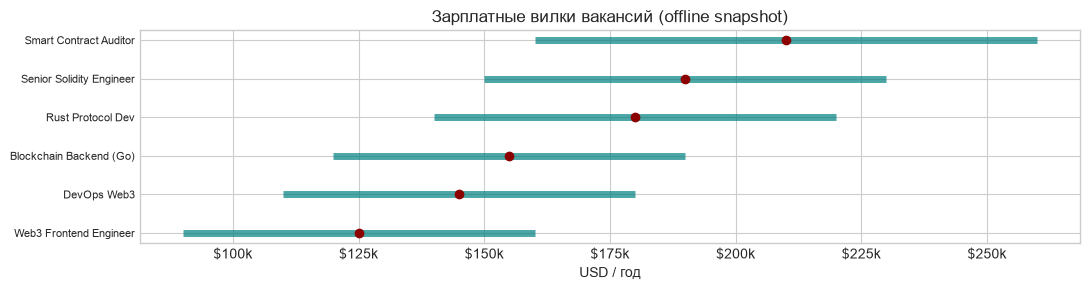

In [11]:
# Анализ зарплатных вилок из живого/оффлайн среза
sal = live.dropna(subset=['salary_min', 'salary_max']).copy()
sal = sal[(sal['salary_min'] > 0) & (sal['salary_max'] > 0)]
if len(sal):
    sal['salary_mid'] = (sal['salary_min'] + sal['salary_max']) / 2
    print(f'Источник: {src} | вакансий с указанной зарплатой: {len(sal)}')
    print('Медианная вилка: ${:,.0f} – ${:,.0f}'.format(
        sal['salary_min'].median(), sal['salary_max'].median()))
    fig, ax = plt.subplots(figsize=(11, max(3, 0.4*len(sal))))
    s = sal.sort_values('salary_mid')
    y = np.arange(len(s))
    ax.hlines(y, s['salary_min'], s['salary_max'], color='teal', lw=5, alpha=0.7)
    ax.scatter(s['salary_mid'], y, color='darkred', zorder=3)
    ax.set_yticks(y); ax.set_yticklabels(s['position'], fontsize=8)
    ax.set_xlabel('USD / год'); ax.set_title(f'Зарплатные вилки вакансий ({src})')
    ax.xaxis.set_major_formatter(lambda x, _: f'${x/1000:.0f}k')
    plt.tight_layout(); plt.show()
else:
    print('В срезе нет вакансий с явно указанной зарплатой (частая ситуация в крипто).')

## 8. Выводы для разработчика

- **Максимум денег:** ZK Engineer, Security Auditor и Protocol Engineer — топ по
  senior-зарплате ($250–280k), но у них выше доля оплаты в токенах (риск) и/или
  ниже спрос.
- **Баланс деньги+спрос+стабильность:** Smart Contract (Solidity) и Blockchain
  Backend — большой спрос при высокой зарплате и умеренном риске.
- **Низкий порог входа + спрос:** Frontend/Full-Stack Web3 — самые массовые
  вакансии, ниже зарплата, но легко перейти из обычного web-разработчика.
- **Грейды:** наибольший относительный прирост дохода даёт переход
  junior→middle (в среднем ~60%); middle→senior тоже весомый (~45%) —
  быстрее всего растёт доход на ранних грейдах.
- **Токены:** ждать «в среднем» апсайда можно (правый хвост LogNormal тянет
  среднее вверх), но вероятность получить **меньше номинала ≈50%**, а «просадка»
  бывает глубокой. Не считай токен-грант гарантированным доходом.

### Как использовать
Подставь свои приоритеты в веса сценария (раздел 5), обнови живой срез RemoteOK
(раздел 6) и получишь персональный список ролей под свою стратегию.

## 9. Источники и оговорки

**Источники (2024–2025):**
- web3.career — агрегатор зарплат по Web3-ролям и стекам;
- CryptoJobsList, Cryptocurrency Jobs — вакансии и вилки;
- Electric Capital *Developer Report 2024/25* — активность разработчиков по экосистемам;
- Stack Overflow Developer Survey 2024 — зарплаты по стекам;
- RemoteOK API — живые удалённые вакансии.

**Оговорки:**
- Зарплаты в крипто имеют огромный разброс (стадия проекта, токеномика, регион
  найма) — цифры это **медианные ориентиры**, не оффер.
- `token_pct` и волатильность ($\sigma=0.8$) — экспертные допущения для учебной
  модели риска, а не гарантия.
- Живой блок зависит от доступности RemoteOK и формата их ответа.

## 10. Упражнения

1. **Стек-премия.** Сравни senior-зарплату Solidity / Rust / ZK. На сколько % ZK
   дороже Solidity? Построй рейтинг стеков по деньгам.
2. **Риск токенов (Монте-Карло).** Проварьируй $\sigma \in \{0.4, 0.8, 1.2\}$ и
   `token_pct`. Посчитай $P(C_{real} < 0.5\,C)$ и риск-скорректированную
   компенсацию (среднее − стандартное отклонение).
3. **Контрактор vs штат.** Смоделируй налог самозанятого/контрактора на доход
   $150k (например, US self-employment ~15.3% + подоходный, или своя страна) и
   сравни чистыми со штатной позицией.
4. **Живые данные.** Подтяни RemoteOK API, посчитай число вакансий по крипто-тегам
   и сравни распределение с оффлайн-срезом.
5. **Персональный рейтинг.** Задай свои веса (деньги/спрос/стабильность) и выбери
   целевую роль; проверь устойчивость выбора к изменению весов ±0.1.

> Решения — в `solutions/22_Solutions.ipynb`.